**Question a)**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
k = 3.2e-13
N = 30000.0
G = 30.0
CL_star = 6.0
Vm = 16.0
Ks = 7.0
KCL = 0.3
YOS = 5.0
YPS = 1.5

S0 = 100.0
CL0 = 6.0
P0 = 0.0

y0 = [S0, CL0, P0]

CL_lim = 3 * KCL

kLa = k * N**3 * np.sqrt(G)

print(f"kLa = {kLa:.3f} h^-1")
print(f"Oxygen limitation threshold = {CL_lim:.3f} mg/L")

kLa = 47.323 h^-1
Oxygen limitation threshold = 0.900 mg/L


In [4]:
def reactor_odes(t, y):
    S, CL, P = y
    
    S = max(S, 0)
    CL = max(CL, 0)
    
    rs = Vm * (S / (Ks + S)) * (CL / (KCL + CL))

    dSdt = -rs
    dCLdt = kLa * (CL_star - CL) - YOS * rs
    dPdt = YPS * rs
    
    return [dSdt, dCLdt, dPdt]

In [5]:
t_span = (0, 20)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

sol = solve_ivp(
    reactor_odes,
    t_span,
    y0,
    t_eval=t_eval,
    method="BDF",
    rtol=1e-8,
    atol=1e-10
)

t = sol.t
S = sol.y[0]
CL = sol.y[1]
P = sol.y[2]

CL_min = np.min(CL)

print(f"Minimum CL = {CL_min:.3f} mg/L")

if CL_min > CL_lim:
    print("The system is NOT oxygen limited.")
else:
    print("The system is oxygen limited.")

Minimum CL = 4.521 mg/L
The system is NOT oxygen limited.


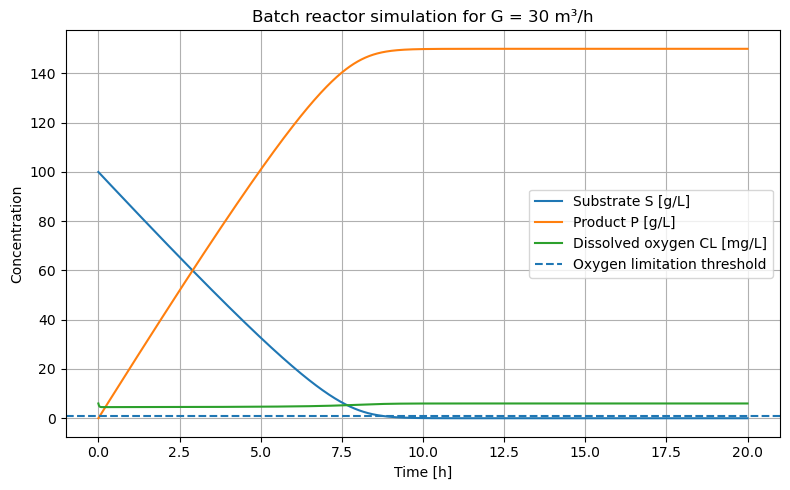

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(t, S, label="Substrate S [g/L]")
plt.plot(t, P, label="Product P [g/L]")
plt.plot(t, CL, label="Dissolved oxygen CL [mg/L]")

plt.axhline(CL_lim, linestyle="--", label="Oxygen limitation threshold")

plt.xlabel("Time [h]")
plt.ylabel("Concentration")
plt.title("Batch reactor simulation for G = 30 m³/h")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()